In [1]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
DATA_DIR = os.path.expanduser("~/pqc/PQC_Communication/Signature-RaspberryPi/results")

paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.jsonl")))
paths

['/home/momo/pqc/PQC_Communication/Signature-RaspberryPi/results/rpi-local_keypair.jsonl',
 '/home/momo/pqc/PQC_Communication/Signature-RaspberryPi/results/rpi-local_sign.jsonl',
 '/home/momo/pqc/PQC_Communication/Signature-RaspberryPi/results/rpi-local_verify.jsonl',
 '/home/momo/pqc/PQC_Communication/Signature-RaspberryPi/results/rpi-local_whole.jsonl']

In [3]:
def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

all_rows = []
for p in paths:
    all_rows.extend(read_jsonl(p))

df = pd.DataFrame(all_rows)
df.head()

,platform,alg,op,iter,msg_len,time_us,heap_used_before,heap_used_after,rss_kb_before,rss_kb_after,peak_rss_kb_before,peak_rss_kb_after,peak_rss_delta_kb,useful_heap_bytes,extra_heap_bytes,static_mem_bytes,total_mem_bytes,pk_len,sk_len,sig_len,ok,t_keypair_us,t_sign_us,t_verify_us,ok_keypair,ok_sign,ok_verify
0,rpi-local,Falcon-512,keypair,0,0,221345,9568,10176,1824,1892,1824,1892,68,2178,0,69632,71810,897,1281,-1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,rpi-local,Falcon-512,keypair,1,0,661186,10176,10464,1892,1892,1892,1892,0,2178,0,0,2178,897,1281,-1,1,NaN,NaN,NaN,NaN,NaN,NaN
2,rpi-local,Falcon-512,keypair,2,0,456012,10464,10520,1892,1892,1892,1892,0,2178,0,0,2178,897,1281,-1,1,NaN,NaN,NaN,NaN,NaN,NaN
3,rpi-local,Falcon-512,keypair,3,0,149948,10520,10576,1892,1896,1892,1896,4,2178,0,4096,6274,897,1281,-1,1,NaN,NaN,NaN,NaN,NaN,NaN
4,rpi-local,Falcon-512,keypair,4,0,131452,10576,10632,1896,1896,1896,1896,0,2178,0,0,2178,897,1281,-1,1,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
num_cols = [
    "iter", "msg_len", "time_us",
    "heap_used_before", "heap_used_after",
    "rss_kb_before", "rss_kb_after",
    "peak_rss_kb_before", "peak_rss_kb_after", "peak_rss_delta_kb",
    "useful_heap_bytes", "extra_heap_bytes",
    "static_mem_bytes", "total_mem_bytes",
    "pk_len", "sk_len", "sig_len",
    "t_keypair_us", "t_sign_us", "t_verify_us",
    "ok", "ok_keypair", "ok_sign", "ok_verify"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["op"] = df["op"].astype(str).str.lower()
df["alg"] = df["alg"].astype(str)

# garder seulement les lignes valides
if "ok" in df.columns:
    df_ok = df[df["ok"] == 1].copy()
else:
    df_ok = df.copy()

df_ok[[
    c for c in [
        "platform", "alg", "op", "time_us",
        "peak_rss_delta_kb", "useful_heap_bytes", "total_mem_bytes"
    ] if c in df_ok.columns
]].head()

,platform,alg,op,time_us,peak_rss_delta_kb,useful_heap_bytes,total_mem_bytes
0,rpi-local,Falcon-512,keypair,221345,68,2178,71810
1,rpi-local,Falcon-512,keypair,661186,0,2178,2178
2,rpi-local,Falcon-512,keypair,456012,0,2178,2178
3,rpi-local,Falcon-512,keypair,149948,4,2178,6274
4,rpi-local,Falcon-512,keypair,131452,0,2178,2178


In [18]:
summary = (
    df_ok.groupby(["alg", "op"])
         .agg(
             time_median_us=("time_us", "median"),

             # MÉTRIQUE PRINCIPALE (Raspberry Pi)
             peak_rss_kb=("peak_rss_delta_kb", "median"),

             # métriques complémentaires
             useful_heap_mean=("useful_heap_bytes", "mean"),
             extra_heap_mean=("extra_heap_bytes", "mean"),

             # mémoire globale (optionnel)
             static_mem_max=("static_mem_bytes", "max"),
             total_mem_max=("total_mem_bytes", "max")
         )
         .reset_index()
)

In [22]:
df_ok = df[df["ok"] == 1].copy()

df_ok[[
    c for c in [
        "platform", "alg", "op", "time_us",
        "peak_rss_delta_kb", "useful_heap_bytes", "total_mem_bytes"
    ] if c in df_ok.columns
]].head()

,platform,alg,op,time_us,peak_rss_delta_kb,useful_heap_bytes,total_mem_bytes
0,rpi-local,Falcon-512,keypair,221345,68,2178,71810
1,rpi-local,Falcon-512,keypair,661186,0,2178,2178
2,rpi-local,Falcon-512,keypair,456012,0,2178,2178
3,rpi-local,Falcon-512,keypair,149948,4,2178,6274
4,rpi-local,Falcon-512,keypair,131452,0,2178,2178


In [23]:
op_order = ["keypair", "sign", "verify", "whole"]

time_table = (
    summary.pivot(index="alg", columns="op", values="time_median_us")
           .reindex(columns=op_order)
)

time_table

op,keypair,sign,verify,whole
alg,,,,
Falcon-512,131444.5,25189.5,562.0,135789.5
Falcon-padded-512,96362.0,25530.5,562.0,167677.5
MAYO-1,15167.0,25814.0,13283.0,53848.5
ML-DSA-44,1868.5,4234.5,1868.0,7962.5
RSA-2048,3282303.0,18776.5,5568.5,3075198.0
SPHINCS+-SHA2-128f-simple,8174.5,191439.0,11035.0,211253.0
SPHINCS+-SHA2-128s-simple,548326.5,4463399.0,3942.0,4928406.5
SPHINCS+-SHAKE-128f-simple,78972.0,1959938.5,119037.5,2089054.5
SPHINCS+-SHAKE-128s-simple,5570219.0,42081033.5,40938.0,47755383.0


In [30]:
mem_table = (
    summary.pivot(index="alg", columns="op", values="useful_heap_mean")
           .reindex(columns=op_order)
)

In [26]:
def plot_grouped_bars(pivot_df, title, ylabel, logy=False):
    pivot_df = pivot_df.dropna(how="all")
    algos = pivot_df.index.tolist()
    ops = pivot_df.columns.tolist()

    x = np.arange(len(algos))
    width = 0.18

    plt.figure(figsize=(12, 6))
    for i, op in enumerate(ops):
        values = pivot_df[op].values
        plt.bar(x + (i - (len(ops)-1)/2)*width, values, width=width, label=op)

    plt.xticks(x, algos, rotation=45, ha="right")
    plt.xlabel("Algorithme")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(title="Opération")
    if logy:
        plt.yscale("log")
    plt.tight_layout()
    plt.show()

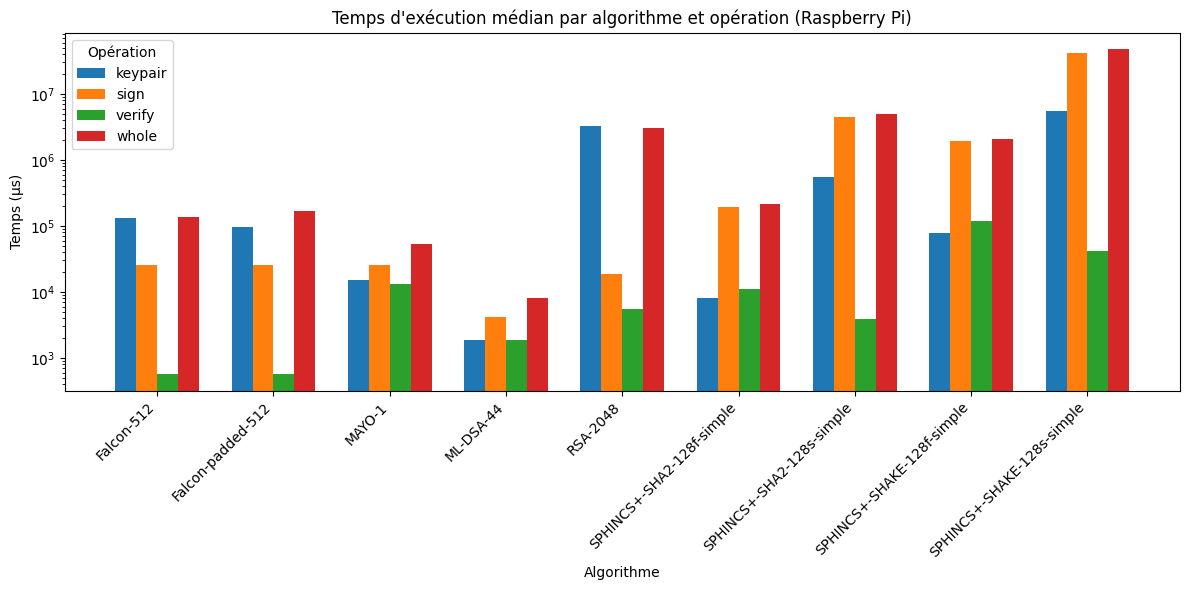

In [31]:
plot_grouped_bars(
    time_table,
    "Temps d'exécution médian par algorithme et opération (Raspberry Pi)",
    "Temps (µs)",
    logy=True
)

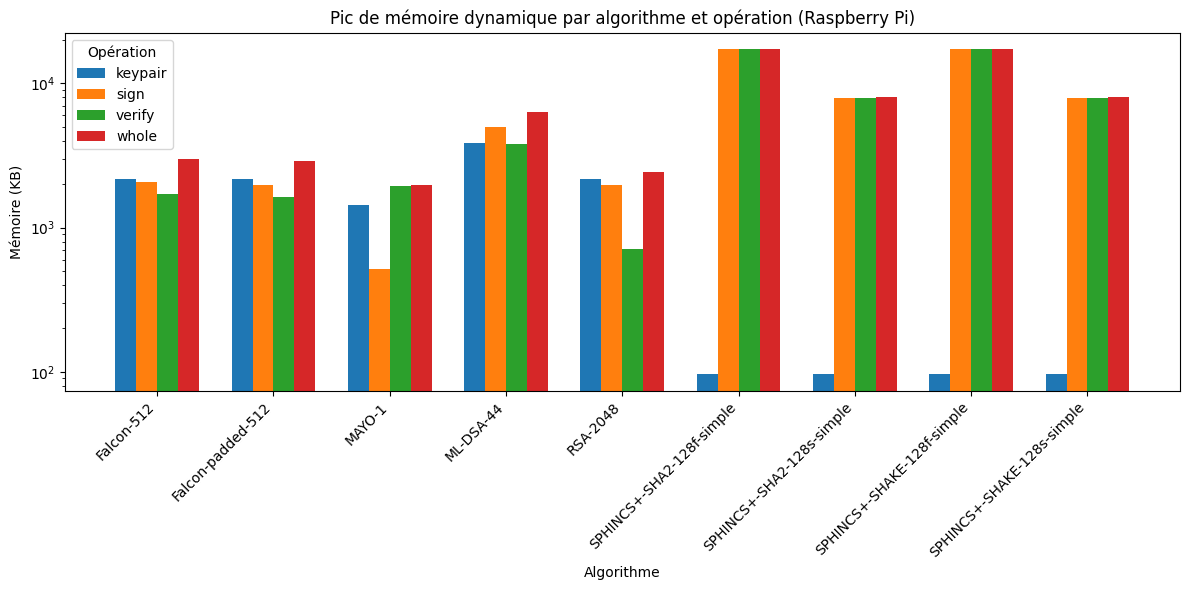

In [32]:
plot_grouped_bars(
    mem_table,
    "Pic de mémoire dynamique par algorithme et opération (Raspberry Pi)",
    "Mémoire (KB)",
    logy=True
)

In [ ]:
plot_grouped_bars(
    mem_table,
    "Pic de mémoire dynamique par algorithme et opération (Raspberry Pi)",
    "Mémoire (KB)",
    logy=True
)

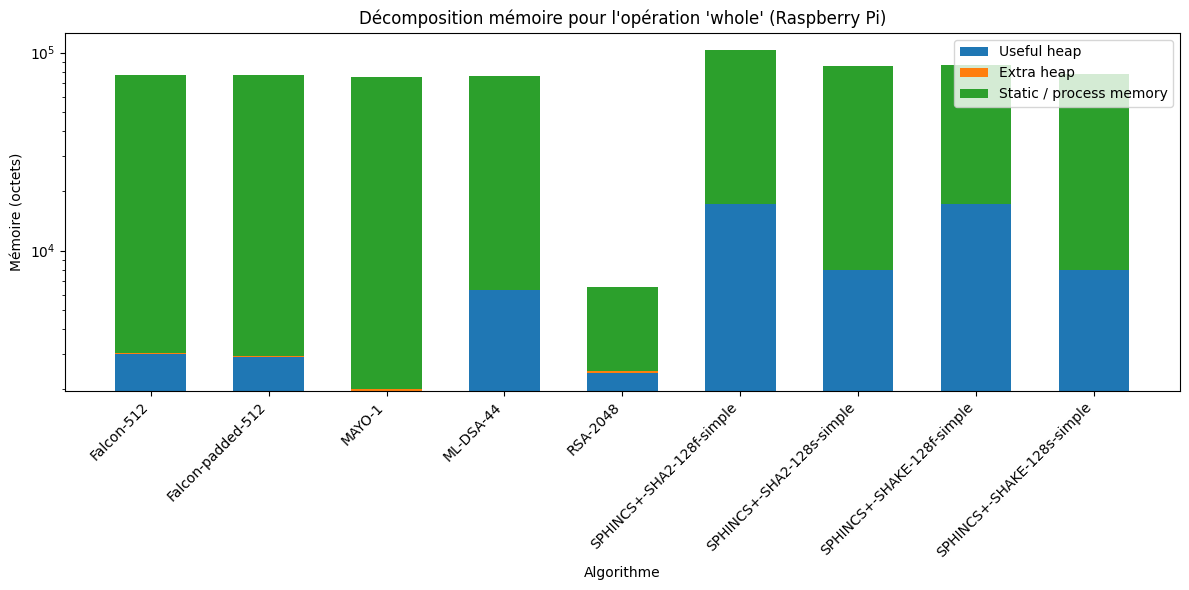

In [13]:
whole_mem = summary[summary["op"] == "whole"].copy().sort_values("alg")

x = np.arange(len(whole_mem))
width = 0.6

plt.figure(figsize=(12, 6))
plt.bar(x, whole_mem["useful_heap_mean"], width=width, label="Useful heap")
plt.bar(
    x,
    whole_mem["extra_heap_mean"],
    width=width,
    bottom=whole_mem["useful_heap_mean"],
    label="Extra heap"
)
plt.bar(
    x,
    whole_mem["static_mem_max"],
    width=width,
    bottom=whole_mem["useful_heap_mean"] + whole_mem["extra_heap_mean"],
    label="Static / process memory"
)

plt.xticks(x, whole_mem["alg"], rotation=45, ha="right")
plt.xlabel("Algorithme")
plt.ylabel("Mémoire (octets)")
plt.title("Décomposition mémoire pour l'opération 'whole' (Raspberry Pi)")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

\paragraph{Performance temporelle}

Les résultats expérimentaux obtenus sur Raspberry Pi montrent que l'algorithme ML-DSA-44 présente les meilleures performances globales parmi les schémas évalués. Les opérations de génération de clé, de signature et de vérification sont exécutées en quelques millisecondes seulement, ce qui en fait une solution particulièrement adaptée aux environnements embarqués.

Falcon-512 offre également de bonnes performances, notamment pour l'opération de vérification qui est particulièrement rapide. Cependant, la génération de clé reste plus coûteuse que pour ML-DSA.

Les schémas SPHINCS+ présentent des temps d'exécution significativement plus élevés, en particulier pour l'opération de signature, qui peut atteindre plusieurs centaines de millisecondes voire plusieurs secondes. Cette caractéristique est liée à la nature hash-based du schéma.

Enfin, RSA-2048 présente des performances intermédiaires, avec une signature relativement rapide mais une génération de clé beaucoup plus coûteuse.

\paragraph{Consommation mémoire}

L'analyse de l'empreinte mémoire montre que la majorité des schémas utilisent entre 70 KB et 90 KB de mémoire totale sur la plateforme Raspberry Pi. RSA-2048 présente l'empreinte mémoire la plus faible, tandis que les schémas SPHINCS+ consomment légèrement plus de mémoire en raison des structures d'arbres de hachage utilisées.

La décomposition mémoire indique que la majorité de la mémoire utilisée correspond à la mémoire statique du processus, tandis que les allocations dynamiques restent relativement faibles.